# Decision Trees

**🎯 Lesson Objectives**

**By the end of this lesson, you will be able to:**
- **Understand Decision Trees** and how they make predictions.  
- **Train Decision Trees** using splitting techniques.  
- **Improve Models** by preventing overfitting and using pruning.  
- **Handle Challenges** like missing values and imbalanced data.  
- **Explore Random Forests** for better accuracy.  
- **Know Pros and Cons** of decision trees.  

  

**🎯What we will cover:**
- **Understand Decision Trees**  
  - Learn how decision trees work and their structure.  
  - Understand how they split data and make predictions.  
  
- **Train Decision Trees**  
  - Use **Gini impurity** and **information gain** to split nodes.  
  - Build decision trees for classification and regression.  
  
- **Improve Model Performance**  
  - Prevent overfitting with **pruning techniques**.  
  - Optimize model depth and complexity for better results.  
  
- **Handle Challenges in Decision Trees**  
  - Manage **missing values** and **imbalanced data**.  
  - Apply techniques to reduce model variance and improve accuracy.  
  
- **Explore Advanced Techniques**  
  - Understand how **random forests** enhance decision trees.  
  - Learn when to use decision trees vs. ensemble methods.  
  
- **Assess the Pros and Cons of Decision Trees**  
  - Recognize their advantages, such as **interpretability and flexibility**.  
  - Understand their limitations, including **overfitting and sensitivity to data changes**.  

## **🔄 Recap: Key Elements from the Pre-Learning**  

Before learning **Decision Trees** in Machine Learning, it is important to understand some fundamental concepts. Below is an overview of key topics to grasp before diving into Decision Trees.

### **1. What is a Decision Tree?**
- A **decision tree** is a machine learning model used for:
  - **Classification** (e.g., deciding if an email is spam or not).
  - **Regression** (e.g., predicting house prices).
- It works like a **flowchart**, where:
  - Each **node** asks a question (e.g., "Is the fruit red?").
  - Each **branch** leads to another question or a final answer.
  - The final answer is at a **leaf** (end of the path).


### **2. How Does a Decision Tree Work?**
- It **learns from data** instead of being manually programmed.
- It follows a step-by-step process to make predictions.
- **Example**: A tree can classify fruits based on color, weight, and shape.


### **3. Where Are Decision Trees Used?**
- **Banks**: Checking if a person is eligible for a loan.
- **Hospitals**: Helping doctors diagnose diseases.
- **Business**: Predicting which customers might stop using a service.
- **Farming**: Helping farmers decide the best time to plant crops.


### **4. Important Terms in Decision Trees**
- **Root Node**: The first question (e.g., "Is the fruit red?").
- **Splitting**: Dividing data into smaller groups.
- **Leaf Node**: The final decision (e.g., "This is an apple.").
- **Parent & Child Nodes**: One node (parent) leads to another (child).

---


# 🚀 Decision Trees 

Decision trees are a simple yet powerful machine learning approach that **learns decision rules from data** rather than being manually defined. They function like flowcharts, making decisions based on input properties.  

- Consist of **binary if-else rules** 
- Rules are **learned from data**, not hand-crafted.  
- The algorithm finds the best thresholds to **separate categories**, e.g., distinguishing apples from cherries based on a 50g weight limit.  

### Decision trees example:

* A **hierarchical** structure
* Each **node** corresponds to a **binary rule**
* Only **one attribute** is considered per node
* The **end** of a decision path is called a **leaf**
* **Follow** the decision path to make **predictions** for new data
* Paths don't interact, **lacking compositional** computations

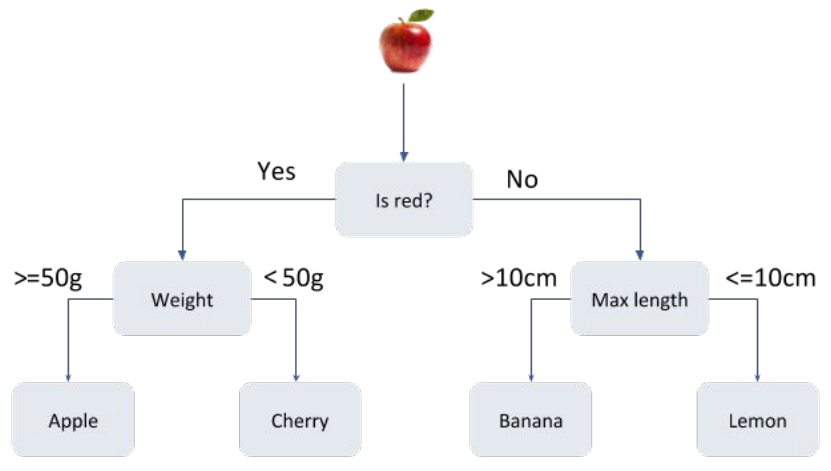


Consider a decision tree that classifies fruits based on their properties. As we traverse the tree, each node presents a binary decision such as "is it red?" and we follow the corresponding branch based on the input feature. When we reach a leaf node, it is assigned a category label. Learning the appropriate thresholds and labels for the tree from data is a crucial step, which we will explore further.

Let's discuss some defining properties of decision trees. Decision trees have a hierarchical structure, which means that the rules that govern the model have an order. 

Decision trees are composed of nodes, each of which corresponds to a binary rule.

Only one attribute is considered per node, and as a result, the rules typically have the form of a question, with an answer "yes" or "no".
- For categorical variables, the rule asks about a specific value of the variable, for example "is red?" for the colour variable.
- For continuous variables, a splitting point is selected, for example "less than 50g?" for weight.

The end of a decision path is called a leaf, and in order to make a prediction for a new example, we follow the decision path until it reaches a leaf.

The node can be compared to a threshold activation unit in neural networks, acting on a single input feature. Since the different paths of the decision tree do not interact, it lacks the compositional properties of neural networks.

#### 💡 Knowledge Check 1

In a **Decision Tree**, what does each decision node represent?

- **A)** A set of multiple conditions evaluated simultaneously.
- **B)** A point where the data is split, based on a condition.
- **C)** A leaf node that makes the final prediction.
- **D)** A compositional structure that interacts with multiple decision paths.

In [1]:
#put your answer below


---


### ✅ Growing the tree

How can we fit a decision tree classifier? We grow from each node, recursively, choosing the "best separation" for that node.

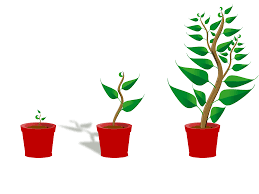

### ✅ Recursive binary splitting

Simple **divide-and-conquer** recursive algorithm, choosing **greedily** the best separation for each new node, until a stopping condition is met.

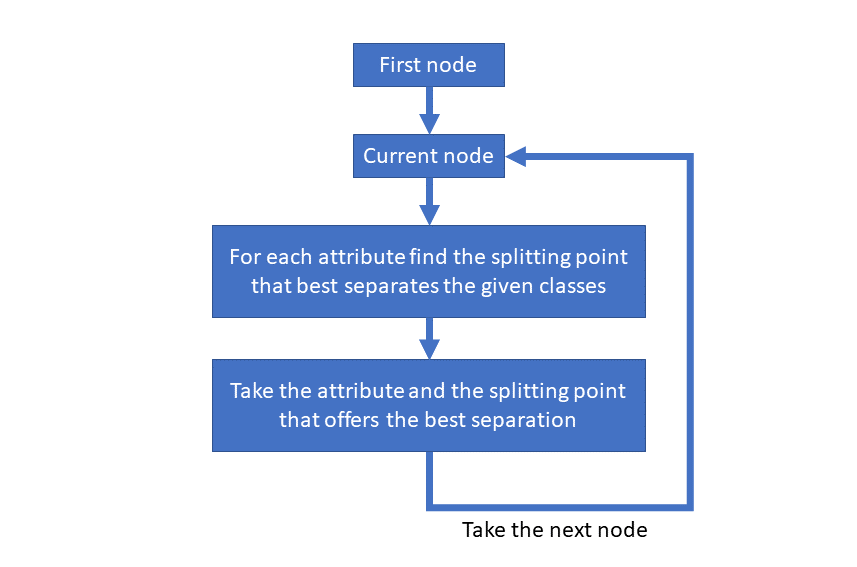

Key questions:
- How do we quantify the **"best separation"**?
- When do we **stop** creating nodes?

Making a prediction using a decision tree is very simple, but how do we actually train the model?

The process begins with the first node. For each attribute, we find the splitting point that best separates the classes. We can only select one attribute per node, so we use the attribute and the splitting point that offers the best separation. 

To select the best attribute and splitting point, we need to consider all available attributes and splitting points. For categorical variables, the splitting points are in the form of questions about a specific category. However, for numeric or continuous attributes, we need to consider all mid-way points between examples of different classes.

When the decision rule for the first node is selected, we can move to the next node. After this other node is done, we continue with a further node, and so on.

There are two key questions:

1. How do we actually quantify the "best separation"?
2. When should we stop creating nodes?


### ✅ Separation quality

* At each node, the decision tree should separate data samples that reach that node.

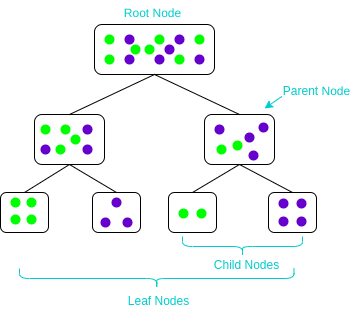

### ✅ Quantifying the best separation
Different metrics can be used to measure "**separation**". Common ones are:
* Gini gain measured through Gini impurity: $I_G = 1-\sum_{i=1}^k p_i^2$ 
* Information gain measure through entropy: $I_H = -\sum_{i=1}^k p_i log_2(p_i)$

Where $p_i$ is the proportion of samples that belong to class $i$ for that node, assuming there are $k$ classes.

There are multiple metrics that can be used to measure the separation of classes in a node. Common ones for categorical data are Gini gain that uses Gini impurity and information gain that is calculated using entropy. They lead to very similar results. The formula for Gini impurity does not involve logarithms, so it is slightly simpler to calculate, but information gain leads to better calibrated proportions when performing probabilistic classification, due to its similarity to cross-entropy loss. 

#### 💡 Knowledge Check 2

When a **Decision Tree** makes a **Split**, what is it trying to achieve?

- **A)** Make the tree as large as possible.
- **B)** Force each leaf to have only one sample.
- **C)** Assign features randomly to the nodes.
- **D)** Separate the data into groups that are purer.

In [2]:
#put your answer below



---



### ✅ Gini impurity

* Intuition of **Gini impurity**: what is the **misclassification** probability for a node when classifying new samples randomly, using a probability distribution proportional to the sample size of each class. For instance, if the node has 7 apples and 3 oranges in its sample, a new data point would be classified as an apple with 70% probability.

* Node $P$ separates a set of examples $S$, with a proportion $p_i$ of samples in class $i$.

* **Gini impurity** for a set $S$ is:
$$G(S)= \sum_{i=1}^k P(\text{misclassified} | \text{sample is class i})  = \sum_{i=1}^k p_i \sum_{j\neq i} p_j = \sum_{i=1}^k p_i \left(1-p_i\right)= 1-\sum_{i=1}^k p_i^2$$
* A lower Gini impurity value indicates better classification performance.

Let's delve into the concept of Gini impurity, considering $k$ classes numbered 1 to $k$. Our focus is on a general node $P$ which divides a set of examples $S$ into two subsets, $S_1$ and $S_2$, based on the attribute values. Within the set $S$, we have a certain proportion of examples belonging to each class, with $p_1$ representing class 1, $p_2$ for class 2, and so on.

To understand Gini impurity better, let's first discuss its underlying idea. This metric calculates the likelihood of a new point being incorrectly classified if we randomly assign it to a class based on the distribution of classes in the dataset. Lower values indicate better results, and hence our goal is to minimise Gini impurity.

### Gini impurity - example
For binary classification, $k=2$. For a set $S$, Gini impurity is $G(S)=1-(p_1^2+p_2^2)$.

For example, if $S$ is a **pure** set with only one class represented, say class 1:
$$p_1=1, p_2=0, \text{ so } G(S)=1-(1^2+0^2)=0.$$

If $S$ is **impure** and has 50% of each class:
$$p_1=0.5, p_2=0.5, \text{ so } G(S)=1-(0.5^2+0.5^2)=0.5.$$

Consider an example to better understand the concept. For binary classification, where $k$ equals two, the formula for Gini impurity is straightforward.

If the set $S$ contains only one class, say class 1, then the probability of class 1 is 1, and the probability of class 2 is 0. Hence, the Gini impurity value is simply $1-(1^2+0^2)=0$.

For an impure set with 50% representation of each class, both $p_1$ and $p_2$ are 0.5, and the Gini impurity value is $1-(0.5^2+0.5^2)=0.5$.

### ✅ Gini impurity values

* In the case of two classes, the maximum impurity occurs when both classes have equal representation in the sample, i.e., 50% for each class.

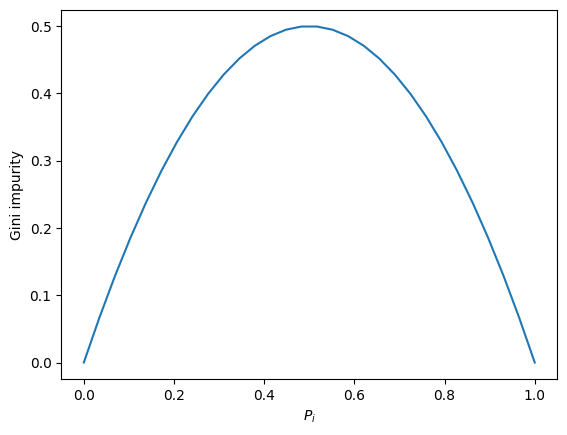

In [3]:
import numpy as np
import matplotlib.pyplot as plt

gini_impurity = lambda probs: 1 - np.sum(probs**2)

probs_range = np.linspace(0, 1, 30)

gini_values = [gini_impurity(np.array([p, 1-p])) for p in probs_range]

plt.plot(probs_range, gini_values);
plt.xlabel("$P_i$");
plt.ylabel("Gini impurity");

### Fitting a tree with Gini impurity

* Reminder: node $P$ separates a set of examples $S$ into subsets $S_1$ and $S_2$ based on the values of the attribute considered
* Question: how to define a **separation criterion** for node $P$ based on the impurity of two subsets, $S_1$ and $S_2$?
* Answer: weighted sum of the Gini impurity of the new nodes

We now know what Gini impurity is. The next step is to actually use Gini impurity for training or fitting a decision tree. Let's remind ourselves what we want to do.

Node $P$ separates a set of examples $S$ into subsets $S_1$ and $S_2$ based on the values of the attribute considered. The question is how to find the **separation criterion** for node $P$. We want to find an attribute and a splitting point that **best** separates the examples.

This leads to a further question: how to **measure** which separation is better? The answer is to use **Gini gain**, which uses Gini impurity as a fundamental part of its calculation.

#### 💡 Knowledge Check 3

What does a low **Gini Impurity** value indicate in a decision tree?

- **A)** Every node must hold exactly one observation only.
- **B)** The classes are mixed in equal proportions.
- **C)** The split was random and not based on quality measures.
- **D)** The node mainly contains one class of samples.
   
  

In [4]:
#put your answer below



---


### ✅ Gini gain

* Gini impurity of the original set $S$ is $G(S)$
* After applying the decision rule at node $P$, the subsets will have Gini impurities $G(S_1)$ and $G(S_2)$ (for binary attributes)
* Sizes of sets $S$, $S_1$, $S_2$ are $|S|$, $|S_1|$, $|S_2|$. $A$ represents the decision rule.
* Formula for Gini gain:
$$Gain_{Gini}(S,A)=G(S)-\sum_{i \in {1,2}} \frac{|S_i|}{|S|}G(S_i)$$

* We want to **maximize** Gini gain.
* We could also divide each node into more than two branches, e.g. into three nodes $S_1$, $S_2$, $S_3$ for three feature values "red", "blue", "yellow", but we focus here on binary splits.

Before we dive into the formula for Gini gain, let's clarify the notation we will be using:

* Gini impurity of the original set $S$ is $G(S)$
* After applying the decision rule at node $P$, the subsets $S_1$ and $S_2$  have Gini impurities denoted as $G(S_1)$ and $G(S_2)$, respectively.
* Sizes of sets $S$, $S_1$, $S_2$ are $|S|$, $|S_1|$, $|S_2|$
* The attribute and the splitting point in question are collectively denoted as $A$
* $\sum_{i \in values(A)}$ means we sum over all possible values of $A$
* Available values for $A$ will usually be 0 and 1 (binary attributes)

The formula for Gini gain is the difference between the Gini impurity of the original set of examples $S$, and the weighted Gini impurities of the subsets based on how many examples they contain. We select the combination of attribute and splitting point (collectively denoted as $A$) that maximizes the Gini gain.

### Gini gain - example

* Imagine we have a dataset that consists of apples and oranges, and the weight of each fruit is recorded. We want to find the optimal decision threshold to divide the dataset into two subsets based on fruit weight.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def gen_data(n_samples = 80):
    random_weight = lambda n=1,mu=150,st=30: np.random.randn(n)*st + mu
    weights = np.array([150,200]) # mean weight (g) for apples and oranges
    prob_apple = 0.4 # probability of apples
    
    labels = np.int32(np.random.rand(n_samples) > prob_apple)
    weights = np.array([random_weight(mu=weights[l]) for l in labels]).reshape(-1)
    
    return weights, labels

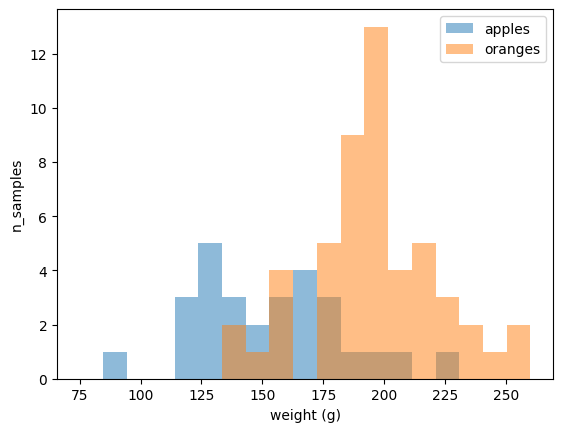

In [6]:
np.random.seed(25)

weights, labels = gen_data(n_samples = 80)

plt.hist(weights[labels==0],alpha=0.5,bins=np.linspace(75,260,20), label="apples");
plt.hist(weights[labels==1],alpha=0.5,bins=np.linspace(75,260,20), label='oranges');
plt.legend(loc='upper right');
plt.xlabel("weight (g)");
plt.ylabel("n_samples");

### Gini gain - optimal decision threshold

* Choose the decision threshold for the weight with highest Gini gain

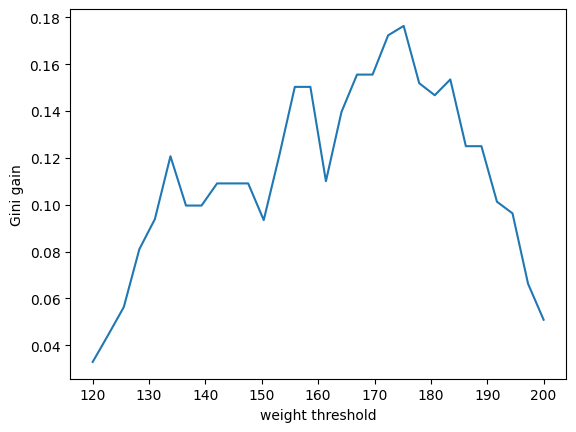

In [7]:
import numpy as np
import matplotlib.pyplot as plt

gini_imp = lambda labs: 1 - np.mean(labs==0)**2 - np.mean(labs==1)**2
gini_gain = lambda S, S1, S2: gini_imp(S) - (len(S1)/len(S))*gini_imp(S1) - (len(S2)/len(S))*gini_imp(S2)

thres = np.linspace(120,200,30) # decision thresholds

gains = [gini_gain(labels, labels[weights<th], labels[weights>th]) for th in thres]

plt.plot(thres,gains);
plt.xlabel("weight threshold")
plt.ylabel("Gini gain");

By calculating the Gini gain for various decision thresholds, we can determine the optimal point for dividing the dataset into two subsets. In this particular example, we observe that the highest Gini gain occurs at approximately 170 grams, which intuitively makes sense when we consider the distribution of each fruit category.

If we choose a lower threshold value, it might effectively separate small apples, but may not work well for other fruit. Conversely, a higher threshold would likely be too mixed and not offer an effective separation.

### ✅ Example: visualize tree

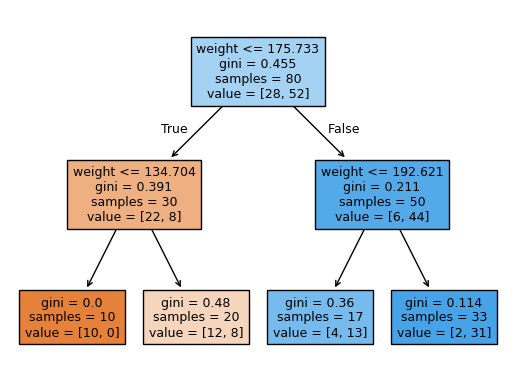

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

dtc = DecisionTreeClassifier(max_depth=2, random_state=25)
dtc.fit(weights.reshape(-1,1), labels)

tree.plot_tree(dtc, filled=True, fontsize=9, feature_names=["weight"]);

It's easy to fit a decision tree and visualize it using Sklearn. For our example, with a depth of 2, the first split is made at weight 175 grams, as we had calculated. The second level of splits divides the weights further. We can observe that the leftmost node, representing weights less than 134g, contains only apples, resulting in a Gini impurity of zero.

### ✅ Regression with decision trees
* Decision trees can also be used for **regression**
* Prediction value of a leaf is defined as the **average** of the target value across training examples in the leaf
* The regression quality of a node is given by the variance of the node target values, $V(S)$. 
* A node with variance zero, $V(S) = 0$, means all samples have same target value, with zero error of the prediction
* Different splitting criterion: **variance reduction**: $$Gain_V = V(S)-\sum_{i \in {1,2}} \frac{|S_i|}{|S|}V(S_i)$$

In addition to classification problems, decision trees can also be used for regression tasks by modifying the approach. To make predictions, we can calculate the average of the target feature for the training examples in the leaf. However, we need a different criterion for splitting than Gini gain, which is used for classification. The alternative criterion for regression is called variance reduction.

As a reminder from logistic regression, we can obtain choice probabilities by passing regression values through the sigmoid or softmax function. We will explore this further later on.

### ✅ Feature importance
* Allows us to find which features are the most important for classification
* Defined as the normalized **Gini gain** for nodes split with the given feature
* Normalized by the probability of reaching the node

$$\text{Feature Importance}=\frac{|S|}{N} \left(G(S) - \frac{|S_1|}{|S|} G(S_1) - \frac{|S_2|}{|S|} G(S_2) \right)$$

Feature importance in decision trees is a measure of the contribution of each feature to the model's performance. It allows us to determine which features are the most important for classification or regression tasks. Feature importance is typically defined as the normalized reduction in impurity (e.g., Gini impurity) that is achieved by splitting on a given feature. The importance is then normalized by the probability of reaching the specific part of the tree where the feature is used for the split. The higher the feature importance, the more relevant that feature is for the classification or regression task.

### ✅ When to stop splitting? Pruning criteria

If we continue splitting the nodes until each observation has a unique path, we end up **overfitting**:
* Unique (*almost!*) decision path for every observation in sample
* Does not generalise well to new data

To prevent overfitting we control the complexity of the tree with pruning criteria:
   * **maximum depth** of any branch
   * **minimum number of samples** needed in a new node/leaf
   * **minimum Gini gain** for a node split
    
How to choose the parameters:
* Evaluate performance on the **validation set**


A crucial aspect of building decision trees is knowing when to stop splitting. Continuously splitting the data can lead to overfitting and result in purely sorted leaf nodes, which do not generalise well. To prevent this, we can implement various strategies such as setting a maximum depth limit, specifying a minimum number of samples required in a new node or leaf, or determining a minimum gain threshold required for a split to occur. These techniques are also referred to as decision tree pruning criteria.

To select appropriate parameters, we can use a validation set. We first select a parameter, fit the model to the training data, and evaluate its performance on the validation set. We then adjust the parameter value until we obtain the best result on the validation set.

In [9]:
#put your answer below



### ✅ Bias vs Variance
* Trade-off between bias and variance relates to the complexity of the model
* Complexity increases with a deeper tree structure.
* Will a decision tree with *max_depth=None* have high or low variance and bias?
* Will a decision tree with *max_depth=2* have high or low variance and bias?

When discussing machine learning models, we often encounter the concept of a trade-off between a model's bias and its variance.

A model with a large bias does not pay much attention to the training data and oversimplifies the modeling process. In the case of decision trees, a model with a low depth has a large bias.

On the other hand, a model with a large variance fits too closely to the training data and has problems generalising to new unseen data. This is the case for fully-grown trees with no limit on the depth.

The trade-off between bias and variance is related to the trade-off in the complexity of the model, so we need to make sure our model is not too simple or too complex. In the context of decision trees this typically relates to finding a suitable depth of the tree.

Bias and variance trade-off is explained well [here](https://towardsdatascience.com/understanding-the-bias-variance-tradeoff-165e6942b229 "Understanding the Bias-Variance Trade-off").

### ✅ Controlling model complexity

For each hyperparameter that regulates the model complexity, there will be a trade-off between fitting the training data and generalising to unseen data.

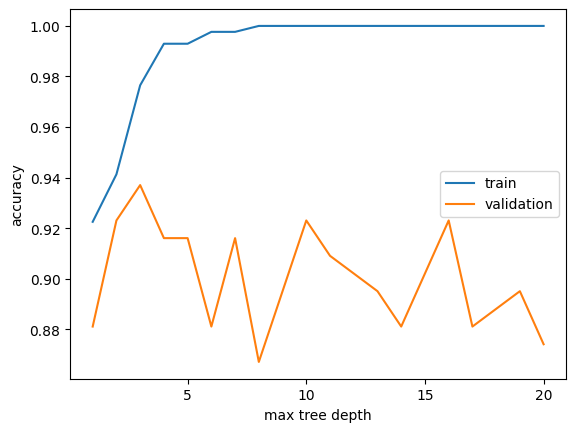

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split

data = sklearn.datasets.load_breast_cancer()

features, features_val, labels, labels_val = train_test_split(data['data'], data['target'], random_state=0)

depths = np.arange(1,21)
dtcs = []
accs = []
val_accs = []

for d in depths:
    dtc_ = DecisionTreeClassifier(max_depth = d) # train trees with different depths
    dtc_.fit(features, labels)
    dtc_.predict(features_val)
    acc = np.mean(dtc_.predict(features) == labels)
    val_acc = np.mean(dtc_.predict(features_val) == labels_val) # accuracy on validation set
    
    dtcs.append(dtc_)
    accs.append(acc)
    val_accs.append(val_acc)
    
plt.plot(depths, accs)
plt.plot(depths, val_accs)
plt.xticks(ticks=np.arange(5,21,5))
plt.xlabel("max tree depth")
plt.ylabel("accuracy");
plt.legend(["train", "validation"]);

With larger depth, the predictions get better for the training data, but it is due to overfitting.

The variability in the validation accuracy is due to the small sample size, but also shows how brittle decision tree training is.

### ✅ Handling missing values

* **Imputation**: same as for other algorithms, fill in with typical values (e.g. median, mode, ...), within class or overall.
* **Null value**: create a categorical attribute for missing values. Good solution when missing values have meaning. E.g. survey subjects with very high income often don't divulge their income.
* **Ignore** while splitting: when calculating the separation gain of each feature, ignore missing values for that feature. At testing, assign samples with missing values for a feature randomly, proportional to number of samples in training for that feature split.

There are multiple approaches to handling missing values for decision tree training. The best choice depends on the number of samples with missing values and the nature of the missing values.

#### 💡 Knowledge Check 4

Which **Max Tree Depth** would you limit your model at?


In [11]:
#put your answer below



### ✅ Random forest

* Single decision tree training can brittle, varying a lot for small changes in the input data
* Random forest: **ensemble** of $k$ decision trees
* Each tree is grown using a **random subset** of all training examples
* Classification of a new example: each tree makes a prediction. Final prediction is done using **majority vote** - most popular class is selected
* The average proportions at each node across the ensemble can be used to generate **probabilities**
* Often offers a very competitive performance

Decision trees can be combined together into ensembles so that they can achieve better performance. In particular, random forest is an ensemble of $k$ decision trees, each of which is grown using a random subset of all training examples.

When classifying a new example, each tree in the forest makes a prediction, and the final prediction is determined through a majority vote. The class that receives the most votes is selected as the final prediction.

Random forests have proven to be highly effective in practice, delivering strong performance across various domains and applications.

### ✅ Pros and cons of decision trees

Let's conclude our lecture by discussing the pros and cons of decision trees.


**Pros:**
* Easy to **interpret**
* No need to **scale** data - no comparisons between features
* Can handle **both** **numerical** and **categorical** data
* Gives access to **features' importance**
* **Compact**
* Making predictions is **fast** - scales with the tree depth
 
**Cons:**
* Can **overfit** easily
* **Not robust**: small variations in data can result in very different results
* **Biased** if the dataset is **imbalanced**



Decision trees have many benefits - they are very easy to interpret, there is no need to scale data (as no comparisons are done between features), they can handle both numerical and categorical data. They allow us to assess the importance of features, which can be valuable for feature selection. They are also compact and efficient in making predictions, with the prediction time scaling with the depth of the tree.


Decision trees have some drawbacks. One of the main challenges is their tendency to overfit the training data, necessitating the use of appropriate parameters and techniques to prevent overfitting. 
They are also sensitive to small variations in the data, which can lead to significantly different results. They can exhibit bias if the dataset is imbalanced, with the majority class dominating the decision-making process. To mitigate the effects of class imbalance, various strategies such as resampling techniques can be employed to address the issue.

#### 💡 Knowledge Check 5

How does a **Random Forest** classifier make its final prediction?

- **A)** It relies only on the single strongest tree in the forest.
- **B)** It randomly picks one of the trees to provide the answer.
- **C)** It takes a majority vote across all the trees in the forest.
- **D)** It always prefers the prediction made by the first tree built.

In [12]:
#put your answer below



### **🔑 Summary / Key Takeaways**
By completing this lesson, you should now be able to:

- ✅ **Understand Decision Trees** and how they make predictions.  
- ✅ **Train Decision Trees** using splitting techniques.  
- ✅ **Improve models** by preventing overfitting and applying pruning.  
- ✅ **Handle challenges** like missing values and imbalanced data.  
- ✅ **Explore Random Forests** for better accuracy.  
- ✅ **Evaluate the pros and cons** of decision trees.  


### **📝 Next Steps:**  

- **Complete the practical lab work**: Open and work through the following workbook:`decision-trees-workbook.ipynb`. 


- **Reinforce Your Learning:** You can start exploring the assignments under the **KATE After Your Workshop** section. Take this opportunity to dive into the tasks and try answering the questions.